In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import my_linear_regression
import my_regularization
import importlib
importlib.reload(my_linear_regression)
importlib.reload(my_regularization)

from my_linear_regression import LinearRegression
from my_regularization import Regularization
lin = LinearRegression()
reg = Regularization()

In [2]:
df = pd.read_csv('data/house_prices/train.csv').set_index('Id')

df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt    

In [4]:
df.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [5]:
null_pct = df.loc[:, (df.isnull().sum() / len(df) > 0.5)].columns
null_pct

Index(['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature'], dtype='object')

In [6]:
df.drop(columns=null_pct, inplace=True)

In [7]:
df.select_dtypes('object').loc[:, (df.select_dtypes('object').nunique() == 1)].columns

Index([], dtype='object')

In [8]:
df.select_dtypes('object').loc[:, (df.select_dtypes('object').nunique() > 30)].columns

Index([], dtype='object')

In [9]:
corr = df.corr(numeric_only=True).abs()
corr['SalePrice'].head()

MSSubClass     0.084284
LotFrontage    0.351799
LotArea        0.263843
OverallQual    0.790982
OverallCond    0.077856
Name: SalePrice, dtype: float64

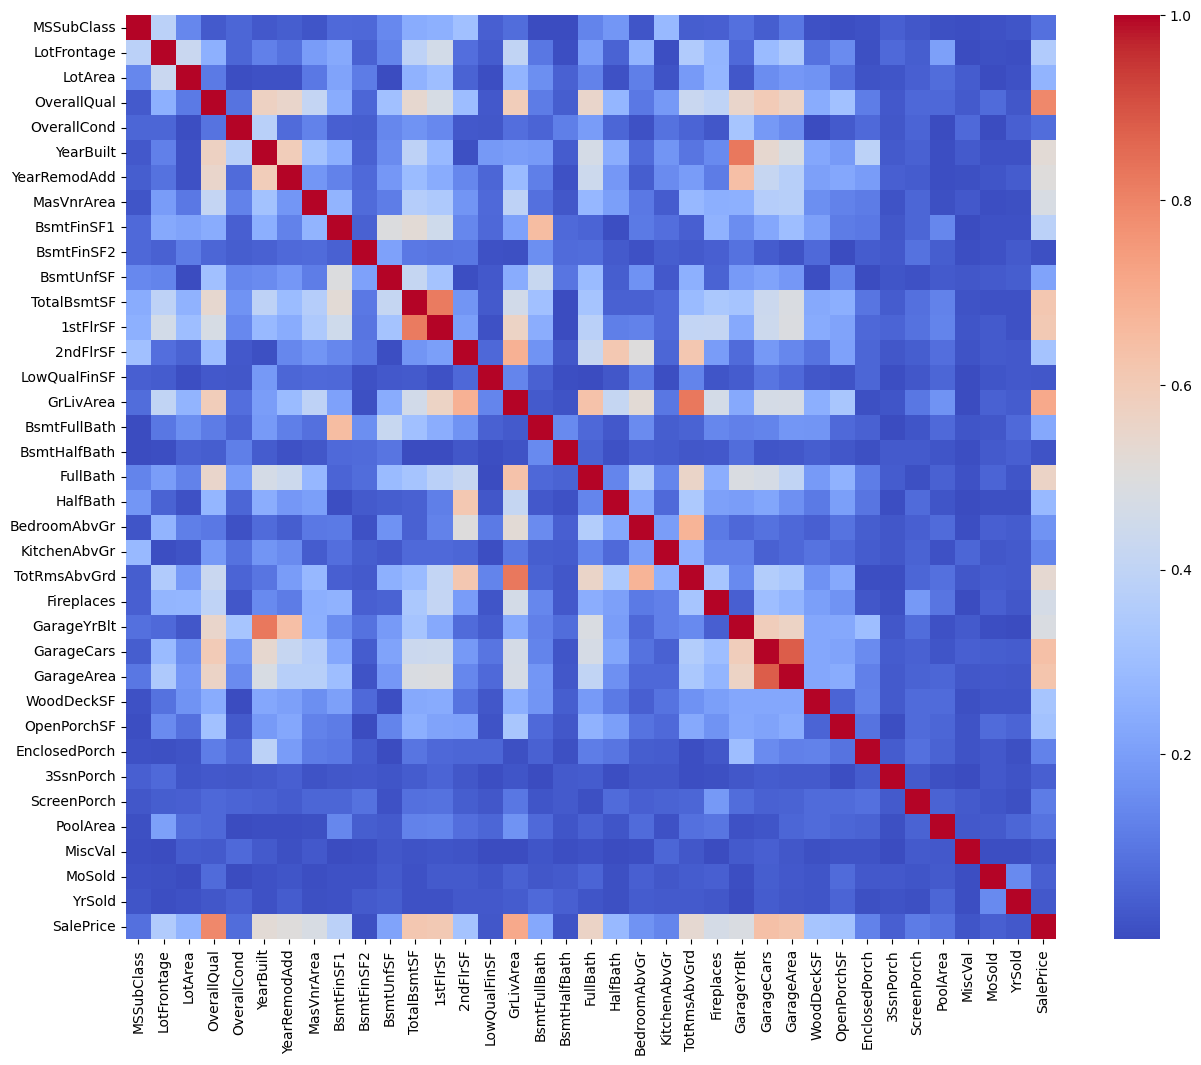

In [10]:
plt.figure(figsize=(15, 12))
sns.heatmap(corr, cmap='coolwarm');

In [11]:
multi_col = ['BsmtUnfSF', 'GarageCars']
df.drop(columns=multi_col, inplace=True)

In [12]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn import set_config
set_config('display')

In [13]:
num_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

num_pipeline

,steps,"[('simpleimputer', ...), ('standardscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [14]:
cat_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore')
)

cat_pipeline

,steps,"[('simpleimputer', ...), ('onehotencoder', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,'auto'


In [15]:
preprocessing = ColumnTransformer([
    ('num', num_pipeline, df.drop('SalePrice', axis=1).select_dtypes('number').columns),
    ('cat', cat_pipeline, df.select_dtypes('object').columns),
    ], remainder='drop')

preprocessing

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [16]:
train_data = pd.read_csv('data/house_prices/train.csv').set_index('Id')
test_data = pd.read_csv('data/house_prices/test.csv').set_index('Id')

In [17]:
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split

In [18]:
X = train_data.drop('SalePrice', axis=1)
y = train_data['SalePrice']

In [19]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=X['OverallQual'], random_state=42)

In [20]:
f'RMSE baseline = {root_mean_squared_error(y_val, [y.mean()] * len(y_val))}'

'RMSE baseline = 92498.93725001377'

In [21]:
X_train_preprocessed = preprocessing.fit_transform(X_train).toarray()
X_val_preprocessed = preprocessing.transform(X_val).toarray()

In [22]:
lin.fit(X_train_preprocessed, y_train)

MSE loss at epoch 0 = 38234929947.63886
MSE loss at epoch 100 = 869979427.1382074
MSE loss at epoch 200 = 759637802.0197682
MSE loss at epoch 300 = 705679385.2277055
MSE loss at epoch 400 = 671345278.6710454
MSE loss at epoch 500 = 646955891.9727265
MSE loss at epoch 600 = 628573012.808358
MSE loss at epoch 700 = 614174310.1056831
MSE loss at epoch 800 = 602562851.830042
MSE loss at epoch 900 = 592969793.3246034
MSE loss at epoch 1000 = 584952016.9672551


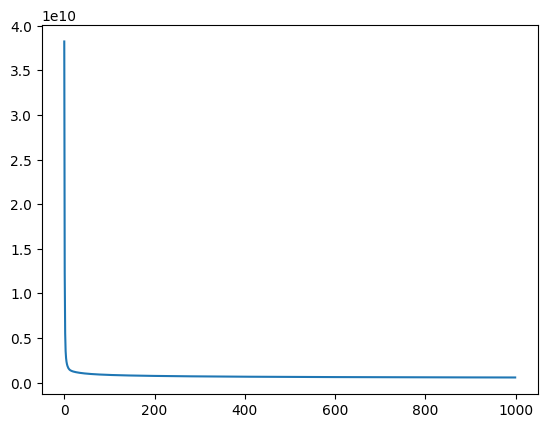

In [23]:
losses = lin.losses_

plt.plot(losses)
plt.show()

In [24]:
from sklearn.metrics import root_mean_squared_error

y_pred_train = lin.predict(X_train_preprocessed)
y_pred_val = lin.predict(X_val_preprocessed)

root_mean_squared_error(y_train, y_pred_train), root_mean_squared_error(y_val, y_pred_val)

(24184.23531714344, 42998.23954426335)

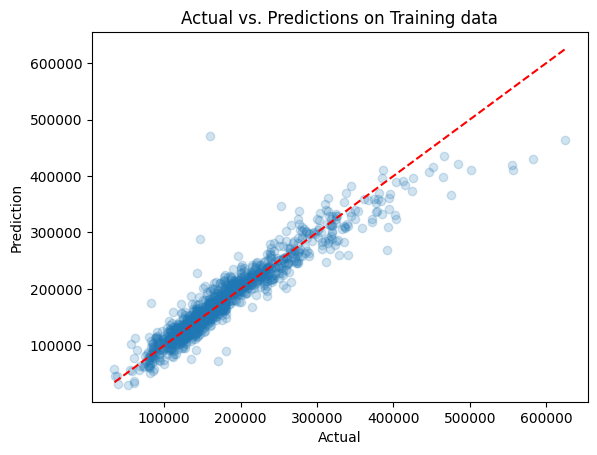

In [25]:
plt.scatter(y_train, y_pred_train, alpha=0.2)
plt.plot(
    [y_train.min(), y_train.max()],
    [y_train.min(), y_train.max()],
    'r--'
)

plt.xlabel('Actual')
plt.ylabel('Prediction')
plt.title('Actual vs. Predictions on Training data')

plt.show()

In [26]:
test_data.drop(null_pct, axis=1, inplace=True)
test_data.drop(multi_col, axis=1, inplace=True)

In [27]:
preprocessed_test_data = preprocessing.transform(test_data).toarray()

y_pred_test = lin.predict(preprocessed_test_data)

y_pred_test

array([114252.38946283, 156902.68646121, 167102.18846446, ...,
       160633.59690852, 111576.73757449, 226630.65680617], shape=(1459,))

In [28]:
output_df = pd.DataFrame(
    y_pred_test,
    index=test_data.index,
    columns=['SalePrice']
)

output_df.head()

,SalePrice
Id,
1461,114252.389463
1462,156902.686461
1463,167102.188464
1464,191619.989149
1465,193620.266424


In [29]:
output_df.to_csv('data/house_prices/submission.csv')

Kaggle Score = 0.15063

In [30]:
lin.fit(X_train_preprocessed, y_train, learning_rate=0.02, loss_function='rmse')

RMSE loss at epoch 0 = 195537.54101869764
RMSE loss at epoch 100 = 27557.311377290956
RMSE loss at epoch 200 = 25908.485081682953
RMSE loss at epoch 300 = 25070.184790176354
RMSE loss at epoch 400 = 24546.34131901826
RMSE loss at epoch 500 = 24183.649888716147
RMSE loss at epoch 600 = 23913.14613572347
RMSE loss at epoch 700 = 23699.739155420022
RMSE loss at epoch 800 = 23524.2903458857
RMSE loss at epoch 900 = 23375.702684253025
RMSE loss at epoch 1000 = 23248.343838724373


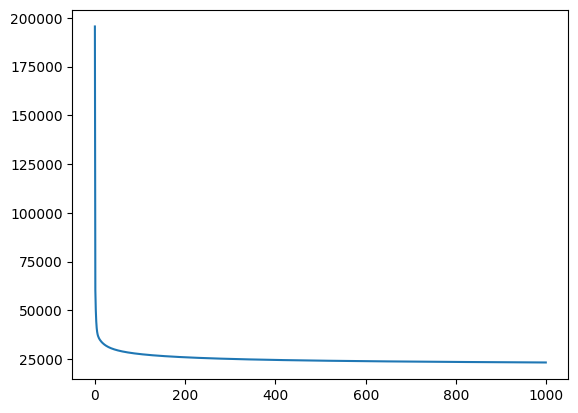

In [31]:
losses = lin.losses_

plt.plot(losses)
plt.show()

In [32]:
y_pred_train = lin.predict(X_train_preprocessed)
y_pred_val = lin.predict(X_val_preprocessed)

root_mean_squared_error(y_train, y_pred_train), root_mean_squared_error(y_val, y_pred_val)

(23247.141316302183, 42160.1086044574)

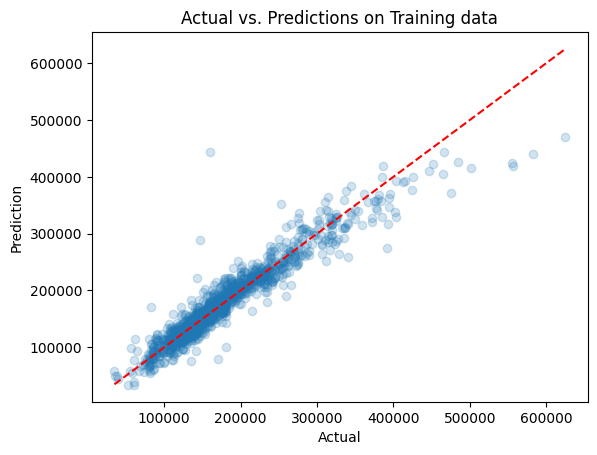

In [33]:
plt.scatter(y_train, y_pred_train, alpha=0.2)
plt.plot(
    [y_train.min(), y_train.max()],
    [y_train.min(), y_train.max()],
    'r--'
)

plt.xlabel('Actual')
plt.ylabel('Prediction')
plt.title('Actual vs. Predictions on Training data')

plt.show()

In [34]:
y_pred_test = lin.predict(preprocessed_test_data)

y_pred_test

array([115825.81140334, 152170.53069415, 165215.12265887, ...,
       158834.61078001, 108257.49081542, 221863.86259094], shape=(1459,))

In [35]:
output_df = pd.DataFrame(
    y_pred_test,
    index=test_data.index,
    columns=['SalePrice']
)

output_df.head()

,SalePrice
Id,
1461,115825.811403
1462,152170.530694
1463,165215.122659
1464,185637.366097
1465,199221.271840


In [36]:
output_df.to_csv('data/house_prices/submission2.csv')

Kaggle Score = 0.14895